In [1]:
# IMPORTS
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.layers import Activation
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [2]:
# DATA PREPROCESSING
img_width, img_height, img_num_channels = 32, 32, 3

# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Input shape
input_shape = (img_width, img_height, img_num_channels)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
# Normalize data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [4]:
def compile_and_train(model, name, epochs=10, batch_size=64):
    model.compile(
        optimizer=Adam(),
        loss=sparse_categorical_crossentropy,
        metrics=['accuracy']
    )

    print(f"\nTraining {name}...\n")
    history = model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    return history

LeNet Model (Simple CNN)

In [5]:
def build_lenet():
    model = Sequential([
        Conv2D(6, (5,5), activation='relu', input_shape=input_shape),
        MaxPooling2D(),

        Conv2D(16, (5,5), activation='relu'),
        MaxPooling2D(),

        Flatten(),
        Dense(120, activation='relu'),
        Dense(84, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

lenet = build_lenet()
history_lenet = compile_and_train(lenet, "LeNet")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training LeNet...

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3836 - loss: 1.6875 - val_accuracy: 0.4661 - val_loss: 1.4729
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4871 - loss: 1.4207 - val_accuracy: 0.5187 - val_loss: 1.3475
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5351 - loss: 1.2969 - val_accuracy: 0.5529 - val_loss: 1.2647
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5715 - loss: 1.2143 - val_accuracy: 0.5636 - val_loss: 1.2435
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5898 - loss: 1.1565 - val_accuracy: 0.5631 - val_loss: 1.2283
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6091 - loss: 1.1084 - val_accuracy: 0.5858 - val_loss: 1.1742
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6208 - loss: 1.0707 - val_accuracy: 0.5996 - val_loss: 1.1385
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6361 - loss: 1.03

AlexNet (Modified for CIFAR-10)

In [6]:
def build_alexnet():
    model = Sequential([
        Conv2D(64, (3,3), activation='relu', padding='same', input_shape=input_shape),
        MaxPooling2D(),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D(),

        Conv2D(256, (3,3), activation='relu', padding='same'),
        MaxPooling2D(),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model

alexnet = build_alexnet()
history_alexnet = compile_and_train(alexnet, "AlexNet")


Training AlexNet...

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.4078 - loss: 1.5936 - val_accuracy: 0.5773 - val_loss: 1.1739
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6025 - loss: 1.1306 - val_accuracy: 0.6688 - val_loss: 0.9588
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6766 - loss: 0.9317 - val_accuracy: 0.7070 - val_loss: 0.8502
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7233 - loss: 0.8063 - val_accuracy: 0.7299 - val_loss: 0.7676
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7550 - loss: 0.7152 - val_accuracy: 0.7319 - val_loss: 0.7764
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7770 - loss: 0.6483 - val_accuracy: 0.7312 - val_loss: 0.7965
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7986 - loss: 0.5842 - val_accuracy: 0.7537 - val_loss: 0.7296
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8183 - loss: 0

VGG16 (Transfer Learning)

In [8]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

def build_vgg16():
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(10, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

vgg16_model = build_vgg16()
history_vgg16 = compile_and_train(vgg16_model, "VGG16")


Training VGG16...

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.4694 - loss: 1.5128 - val_accuracy: 0.5503 - val_loss: 1.2816
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5448 - loss: 1.3009 - val_accuracy: 0.5673 - val_loss: 1.2240
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5645 - loss: 1.2460 - val_accuracy: 0.5872 - val_loss: 1.1830
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5775 - loss: 1.2078 - val_accuracy: 0.5820 - val_loss: 1.1753
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5880 - loss: 1.1804 - val_accuracy: 0.5970 - val_loss: 1.1527
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5943 - loss: 1.1608 - val_accuracy: 0.5989 - val_loss: 1.1387
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.6010 - loss: 1.1435 - val_accuracy: 0.6027 - val_loss: 1.1316
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.60

ResNet50 (Transfer Learning)

In [9]:
from tensorflow.keras.applications import ResNet50

def build_resnet():
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    predictions = Dense(10, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

resnet_model = build_resnet()
history_resnet = compile_and_train(resnet_model, "ResNet50")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training ResNet50...

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.2508 - loss: 2.0559 - val_accuracy: 0.2854 - val_loss: 1.9268
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3186 - loss: 1.8871 - val_accuracy: 0.3437 - val_loss: 1.8566
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3403 - loss: 1.8259 - val_accuracy: 0.3375 - val_loss: 1.7968
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3569 - loss: 1.7889 - val_accuracy: 0.3696 - val_loss: 1.7570
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.3630 - loss: 1.7749 - val_accuracy: 0.3613 - val_loss: 1.7743
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3714 - loss: 1.7460 - val_accuracy: 0.3710 - val_loss: 1.7576
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.3739 - loss: 1.7366 - val_accuracy: 0.3660 - val_loss: 1.7783
Epoch 8/10
782/782 ━

Compare Results (Accuracy Plot)

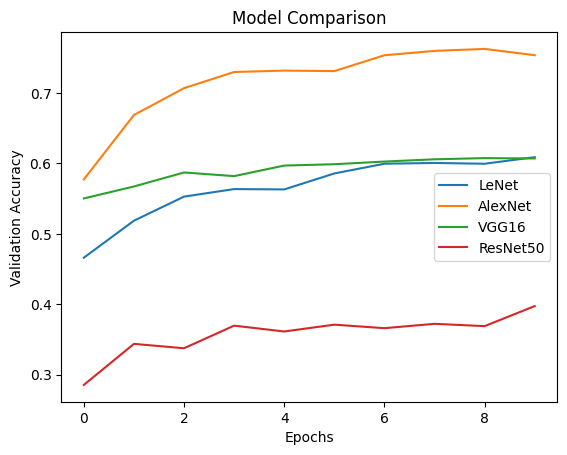

In [10]:
def plot_history(histories, names):
    for history, name in zip(histories, names):
        plt.plot(history.history['val_accuracy'], label=name)

    plt.title("Model Comparison")
    plt.xlabel("Epochs")
    plt.ylabel("Validation Accuracy")
    plt.legend()
    plt.show()

plot_history(
    [history_lenet, history_alexnet, history_vgg16, history_resnet],
    ["LeNet", "AlexNet", "VGG16", "ResNet50"]
)